# XGBoost and feature selection

Compare XGBoost with all features, Ridge-based RFE, and XGBoost-based selection. Keep Ridge with all features as a simple comparison. Choose parameters using the same chronological CV folds for each city.


In [3]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from pathlib import Path
from IPython.display import display

from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import FunctionTransformer, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.feature_selection import VarianceThreshold, RFE, SelectFromModel
from sklearn.linear_model import Ridge
from sklearn.model_selection import TimeSeriesSplit, GridSearchCV
from sklearn.metrics import mean_absolute_error, make_scorer
from xgboost import XGBRegressor

RANDOM_SEED = 2022
np.random.seed(RANDOM_SEED)
sns.set_theme(style="whitegrid")
Path("feature_selection_results").mkdir(exist_ok=True)

## Load the data

In [4]:
df_train_features = pd.read_csv("DengAI_Predicting_Disease_Spread_-_Training_Data_Features.csv")
df_train_labels = pd.read_csv("DengAI_Predicting_Disease_Spread_-_Training_Data_Labels.csv")

df_train = df_train_features.merge(df_train_labels, on=["city", "year", "weekofyear"], validate="one_to_one")
df_train["week_start_date"] = pd.to_datetime(df_train["week_start_date"])
df_train = df_train.sort_values(["city", "week_start_date"])

sj_train_features = df_train.query("city == 'sj'").drop(columns="total_cases").copy()
iq_train_features = df_train.query("city == 'iq'").drop(columns="total_cases").copy()
sj_train_labels = df_train.query("city == 'sj'")["total_cases"].copy()
iq_train_labels = df_train.query("city == 'iq'")["total_cases"].copy()

print("San Juan:", sj_train_features.shape)
print("Iquitos:", iq_train_features.shape)

San Juan: (936, 24)
Iquitos: (520, 24)


## Preprocessing

The imputer, seasonal encoding, and history features are unchanged from the first notebook. Interpolation assumes the full weather block is available; it is not a strictly past-only procedure. All fitted preprocessing and selection stay inside CV.


In [5]:
class DengueImputer(TransformerMixin, BaseEstimator):
    def __init__(self, seasonal_columns=(), copy=False):
        self.seasonal_columns = seasonal_columns
        self.copy = copy

    def fit(self, X, y=None):
        excluded = ["city", "year", "weekofyear", "week_start_date", "total_cases"]
        self.feature_columns_ = [col for col in X.columns if col not in excluded]
        self.interpolation_columns_ = [
            col for col in self.feature_columns_ if col not in self.seasonal_columns
        ]
        self.week_medians_ = X.groupby("weekofyear")[list(self.seasonal_columns)].median()
        self.overall_medians_ = X[list(self.seasonal_columns)].median()
        return self

    def transform(self, X):
        result = X.copy() if self.copy else X

        for col in self.seasonal_columns:
            seasonal_values = result["weekofyear"].map(self.week_medians_[col])
            result[col] = (
                result[col]
                .fillna(seasonal_values)
                .fillna(self.overall_medians_[col])
            )

        result[self.interpolation_columns_] = result[self.interpolation_columns_].interpolate(
            method="linear", limit_area="inside"
        )
        return result

In [6]:
def cyclical_encoding(df):
    dates = pd.to_datetime(df["week_start_date"])

    days_in_year = 365 + dates.dt.is_leap_year.astype(int)
    year_fraction = (dates.dt.dayofyear - 1) / days_in_year
    angle = 2 * np.pi * year_fraction

    df["annual_sin"] = np.sin(angle)
    df["annual_cos"] = np.cos(angle)

    return df


In [7]:
class WeatherHistoryTransformer(TransformerMixin, BaseEstimator):
    def __init__(
        self,
        lag_columns,
        mean_columns,
        sum_columns,
        lags=(1, 2, 4, 8, 10, 20, 26),
        windows=(4, 8, 10, 12, 16, 26),
    ):
        self.lag_columns = lag_columns
        self.mean_columns = mean_columns
        self.sum_columns = sum_columns
        self.lags = lags
        self.windows = windows

    def fit(self, X, y=None):
        history_length = max(max(self.lags), max(self.windows))
        self.history_ = X.tail(history_length).copy()
        return self

    def transform(self, X):
        history = self.history_.loc[
            self.history_["week_start_date"] < X["week_start_date"].iloc[0]
        ]
        result = pd.concat([history, X])
        features = {}

        for col in self.lag_columns:
            for lag in self.lags:
                features[f"{col}_lag_{lag}w"] = result[col].shift(lag)

        for window in self.windows:
            for col in self.sum_columns:
                features[f"{col}_sum_{window}w"] = (
                    result[col].shift(1).rolling(window).sum()
                )

            for col in self.mean_columns:
                features[f"{col}_mean_{window}w"] = (
                    result[col].shift(1).rolling(window).mean()
                )

        features = pd.DataFrame(features, index=result.index)
        result = pd.concat([result, features], axis=1)
        return result.iloc[-len(X):].copy()

mean_columns = [
    "reanalysis_relative_humidity_percent",
    "reanalysis_air_temp_k",
    "reanalysis_specific_humidity_g_per_kg",
    "station_avg_temp_c",
    "station_min_temp_c",
    "station_max_temp_c",
]

sum_columns = [
    "precipitation_amt_mm",
    "station_precip_mm",
]

lag_columns = mean_columns + sum_columns

## Build the pipeline

In [8]:
ndvi_cols = ("ndvi_ne", "ndvi_nw", "ndvi_se", "ndvi_sw")
exclude = ["reanalysis_sat_precip_amt_mm"]


def prepare_features(X):
    X = cyclical_encoding(X.copy())
    return X.drop(columns=["city", "week_start_date"] + exclude)


def make_model(city, estimator, selector="passthrough"):
    return make_pipeline(
        DengueImputer(seasonal_columns=ndvi_cols if city == "sj" else (), copy=True),
        WeatherHistoryTransformer(lag_columns, mean_columns, sum_columns),
        FunctionTransformer(prepare_features),
        SimpleImputer(strategy="median", keep_empty_features=True).set_output(transform="pandas"),
        VarianceThreshold().set_output(transform="pandas"),
        StandardScaler().set_output(transform="pandas"),
        selector,
        estimator,
    )

## Chronological split and score

Reserve the final 52 observations of each city as a holdout.

In [9]:
city_data = {
    "sj": (sj_train_features, sj_train_labels),
    "iq": (iq_train_features, iq_train_labels),
}
city_names = {"sj": "San Juan", "iq": "Iquitos"}
CV = TimeSeriesSplit(n_splits=3, test_size=52)
splits = {}
fold_dates = []

for city, (X, y) in city_data.items():
    X_train, X_holdout = X.iloc[:-52].copy(), X.iloc[-52:].copy()
    y_train, y_holdout = y.iloc[:-52].copy(), y.iloc[-52:].copy()
    splits[city] = (X_train, X_holdout, y_train, y_holdout)
    for fold, (train_idx, valid_idx) in enumerate(CV.split(X_train), start=1):
        fold_dates.append({
            "city": city_names[city], "fold": fold,
            "train_end": X_train.iloc[train_idx[-1]]["week_start_date"],
            "validation_start": X_train.iloc[valid_idx[0]]["week_start_date"],
            "validation_end": X_train.iloc[valid_idx[-1]]["week_start_date"],
        })

display(pd.DataFrame(fold_dates))


def clipped_mae(y_true, y_pred):
    return mean_absolute_error(y_true, np.clip(y_pred, 0, None))


mae_score = make_scorer(clipped_mae, greater_is_better=False)

,city,fold,train_end,validation_start,validation_end
0,San Juan,1,2004-04-22,2004-04-29,2005-04-23
1,San Juan,2,2005-04-23,2005-04-30,2006-04-23
2,San Juan,3,2006-04-23,2006-04-30,2007-04-23
3,Iquitos,1,2006-06-25,2006-07-02,2007-06-25
4,Iquitos,2,2007-06-25,2007-07-02,2008-06-24
5,Iquitos,3,2008-06-24,2008-07-01,2009-06-25


## Compare feature-selection methods

In [11]:
models = {
    "XGBoost": XGBRegressor(objective="reg:squarederror", tree_method="hist", random_state=RANDOM_SEED, n_jobs=1),
}
model_grids = {
    "XGBoost": {
        "xgbregressor__max_depth": [2, 4, 6],
        "xgbregressor__learning_rate": [0.03, 0.1],
        "xgbregressor__n_estimators": [100, 300],
        "xgbregressor__reg_lambda": [1, 10],
    },
}
selectors = {
    "All features": "passthrough",
    "Ridge RFE": RFE(Ridge(alpha=10), step=0.2),
    "Tree selection": SelectFromModel(
        XGBRegressor(n_estimators=100, max_depth=3, learning_rate=0.05,
                     objective="reg:squarederror", tree_method="hist", importance_type="gain",
                     random_state=RANDOM_SEED, n_jobs=1),
        threshold=-np.inf,
    ),
}
selection_grids = {
    "All features": {},
    "Ridge RFE": {"rfe__n_features_to_select": [10, 25, 50, 100]},
    "Tree selection": {"selectfrommodel__max_features": [10, 25, 50, 100]},
}

results = []
searches = {}
cv_trials = []

for city, (X_train, X_holdout, y_train, y_holdout) in splits.items():
    for model_name, estimator in models.items():
        methods = ["All features"] if model_name == "Ridge" else selectors
        for method in methods:
            selection_grid = selection_grids[method]
            search = GridSearchCV(
                make_model(city, estimator, selectors[method]),
                param_grid={**model_grids[model_name], **selection_grid},
                scoring=mae_score, cv=CV, n_jobs=1, error_score="raise",
            )
            search.fit(X_train, y_train)
            searches[(city, model_name, method)] = search
            pipe = search.best_estimator_
            n_features = pipe[-1].n_features_in_
            params = search.best_params_
            results.append({
                "city": city, "model": model_name, "method": method,
                "n_features": n_features,
                "cv_mae": -search.best_score_,
                "cv_std": search.cv_results_["std_test_score"][search.best_index_],
                "parameters": str(params),
            })
            trials = pd.DataFrame(search.cv_results_)
            trials["city"], trials["model"], trials["method"] = city, model_name, method
            cv_trials.append(trials)

results_df = pd.DataFrame(results).sort_values(["city", "cv_mae"])
display(results_df.round(3))

,city,model,method,n_features,cv_mae,cv_std,parameters
4,iq,XGBoost,Ridge RFE,10,6.673,2.361,"{'rfe__n_features_to_select': 10, 'xgbregresso..."
5,iq,XGBoost,Tree selection,25,7.116,2.321,"{'selectfrommodel__max_features': 25, 'xgbregr..."
3,iq,XGBoost,All features,127,7.208,2.230,"{'xgbregressor__learning_rate': 0.03, 'xgbregr..."
1,sj,XGBoost,Ridge RFE,50,13.990,3.977,"{'rfe__n_features_to_select': 50, 'xgbregresso..."
2,sj,XGBoost,Tree selection,100,17.919,5.922,"{'selectfrommodel__max_features': 100, 'xgbreg..."
0,sj,XGBoost,All features,127,17.993,5.429,"{'xgbregressor__learning_rate': 0.1, 'xgbregre..."


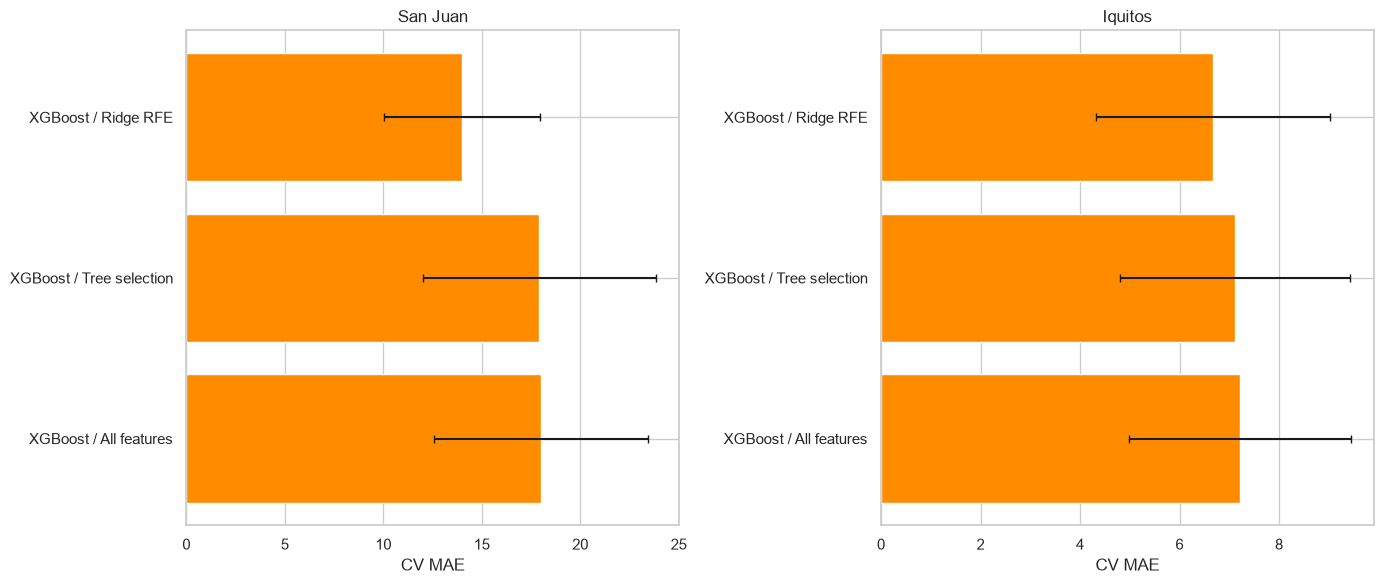

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
for ax, city in zip(axes, ["sj", "iq"]):
    comparison = results_df.query("city == @city").sort_values("cv_mae", ascending=False)
    labels = comparison["model"] + " / " + comparison["method"]
    colors = ["steelblue" if model == "Ridge" else "darkorange" for model in comparison["model"]]
    ax.barh(labels, comparison["cv_mae"], xerr=comparison["cv_std"], color=colors, capsize=3)
    ax.set_title(city_names[city])
    ax.set_xlabel("CV MAE")
plt.tight_layout()
plt.show()

## Selected features

In [13]:
winners = results_df.loc[results_df.groupby(["city", "model"])["cv_mae"].idxmin()]
best_models = {}
selected_features = []

for row in winners.itertuples():
    pipe = searches[(row.city, row.model, row.method)].best_estimator_
    best_models[(row.city, row.model)] = pipe
    names = pipe.named_steps["standardscaler"].get_feature_names_out()
    selector = pipe[-2]
    if selector != "passthrough":
        names = names[selector.get_support()]
    print(f"{city_names[row.city]} / {row.model} / {row.method}: {len(names)} features")
    print(list(names))
    selected_features.extend({"city": row.city, "model": row.model, "feature": name} for name in names)

Iquitos / XGBoost / Ridge RFE: 10 features
['station_max_temp_c_mean_8w', 'station_max_temp_c_mean_10w', 'station_avg_temp_c_mean_16w', 'station_min_temp_c_mean_16w', 'station_max_temp_c_mean_16w', 'precipitation_amt_mm_sum_26w', 'reanalysis_specific_humidity_g_per_kg_mean_26w', 'station_avg_temp_c_mean_26w', 'annual_sin', 'annual_cos']
San Juan / XGBoost / Ridge RFE: 50 features
['year', 'weekofyear', 'reanalysis_avg_temp_k', 'reanalysis_max_air_temp_k', 'reanalysis_relative_humidity_percent', 'reanalysis_specific_humidity_g_per_kg', 'station_diur_temp_rng_c', 'station_max_temp_c', 'reanalysis_air_temp_k_lag_2w', 'reanalysis_air_temp_k_lag_8w', 'reanalysis_air_temp_k_lag_10w', 'reanalysis_air_temp_k_lag_20w', 'reanalysis_specific_humidity_g_per_kg_lag_1w', 'reanalysis_specific_humidity_g_per_kg_lag_2w', 'reanalysis_specific_humidity_g_per_kg_lag_20w', 'reanalysis_specific_humidity_g_per_kg_lag_26w', 'station_avg_temp_c_lag_8w', 'station_avg_temp_c_lag_10w', 'station_avg_temp_c_lag_20w

## Holdout comparison

In [14]:
holdout_results = []
predictions = []

for city, (X_train, X_holdout, y_train, y_holdout) in splits.items():
    baseline_cv = []
    for train_idx, valid_idx in CV.split(X_train):
        baseline_cv.append(mean_absolute_error(y_train.iloc[valid_idx],
                           np.repeat(y_train.iloc[train_idx].median(), len(valid_idx))))
    baseline = np.repeat(y_train.median(), len(y_holdout))
    holdout_results.append({"city": city, "model": "Median", "method": "Constant",
                            "cv_mae": np.mean(baseline_cv),
                            "holdout_mae": mean_absolute_error(y_holdout, baseline)})
    for model_name in models:
        pipe = best_models[(city, model_name)]
        pred = np.clip(pipe.predict(X_holdout), 0, None)
        winner = winners.query("city == @city and model == @model_name").iloc[0]
        holdout_results.append({"city": city, "model": model_name, "method": winner["method"],
                                "cv_mae": winner["cv_mae"],
                                "holdout_mae": mean_absolute_error(y_holdout, pred)})
        predictions.append(pd.DataFrame({"city": city, "model": model_name,
                           "week_start_date": X_holdout["week_start_date"].to_numpy(),
                           "actual": y_holdout.to_numpy(), "predicted": pred}))

holdout_df = pd.DataFrame(holdout_results)
predictions_df = pd.concat(predictions, ignore_index=True)
display(holdout_df.round(3))

,city,model,method,cv_mae,holdout_mae
0,sj,Median,Constant,15.782,27.500
1,sj,XGBoost,Ridge RFE,13.990,14.582
2,iq,Median,Constant,7.346,3.846
3,iq,XGBoost,Ridge RFE,6.673,3.477


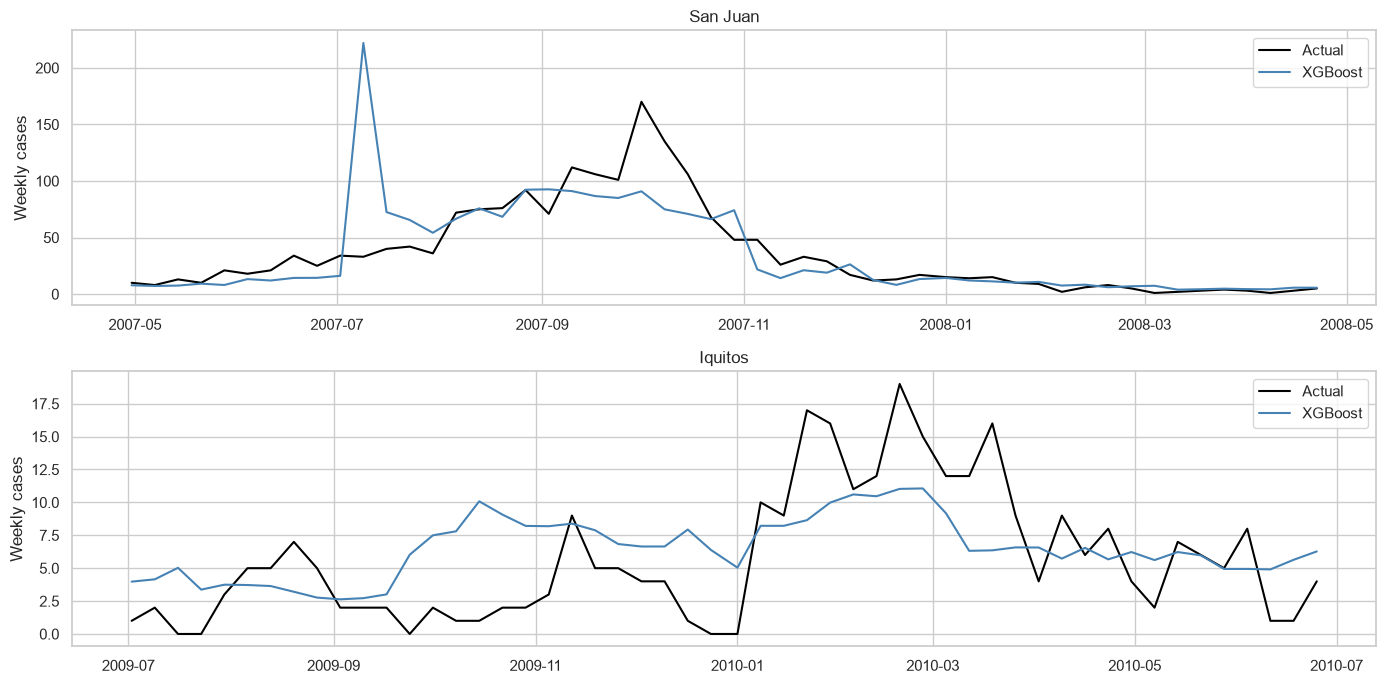

In [15]:
fig, axes = plt.subplots(2, 1, figsize=(14, 7))
for ax, city in zip(axes, ["sj", "iq"]):
    _, X_holdout, _, y_holdout = splits[city]
    ax.plot(X_holdout["week_start_date"], y_holdout, color="black", label="Actual")
    for model_name, color in zip(models, ["steelblue", "darkorange"]):
        pred = predictions_df.query("city == @city and model == @model_name")
        ax.plot(pred["week_start_date"], pred["predicted"], color=color, label=model_name)
    ax.set_title(city_names[city])
    ax.set_ylabel("Weekly cases")
    ax.legend()
plt.tight_layout()
plt.savefig("feature_selection_results/holdout_predictions.png", dpi=200, bbox_inches="tight")
plt.show()